# Анализ облигаций — ежемесячный купон\n\nФильтр: 12 выплат/год, купон ≥ 2% от цены, цена ≥ 97% номинала.

## Пайплайн данных

Весь путь запускается прямо отсюда. По умолчанию тяжёлые шаги выключены и берутся готовые CSV; любой шаг запустится автоматически, если его файла нет. Чтобы обновить данные — поставь соответствующий флаг в `True`.

In [1]:
import os
import fetch_bonds, fetch_bonds_detail, filter_bonds

FETCH_TICKERS = False   # список облигаций с биржи (~30 сек)
FETCH_DETAIL  = False   # детали по каждой бумаге (ДОЛГО, ~25 мин)
RUN_FILTER    = False   # шортлист + флаг залога (~1 мин, дёргает API)

if FETCH_TICKERS or not os.path.exists("bonds_tickers.csv"):
    fetch_bonds.main()

if FETCH_DETAIL or not os.path.exists("bonds_detail.csv"):
    fetch_bonds_detail.main()

if RUN_FILTER or not os.path.exists("bonds_filtered.csv"):
    filter_bonds.main()

print("Данные готовы:", ", ".join(f for f in ["bonds_tickers.csv","bonds_detail.csv","bonds_filtered.csv"] if os.path.exists(f)))

/Users/shilonosovvr/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Данные готовы: bonds_tickers.csv, bonds_detail.csv, bonds_filtered.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(style="whitegrid")

df = pd.read_csv("bonds_filtered.csv")

# типизация
numeric = [
    "price_buy", "price_sell", "price_last", "price_close", "price_pct",
    "face_value", "nkd", "coupon_value", "coupon_pct", "coupon_period_days",
    "coupon_qty_per_year", "yield_to_maturity", "yield_to_client", "total_yield",
    "duration", "rate", "risk_category", "earnings_abs", "earnings_rel",
    "hist_price_1y", "lot_size",
]
for col in numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce")

date_cols = ["next_coupon_date", "maturity_date", "date_to_client"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

df["maturity_years"] = (df["maturity_date"] - pd.Timestamp.now(tz="UTC")).dt.days / 365
df["coupon_to_price_pct"] = df["coupon_value"] / df["price_last"] * 100
df["annual_coupon"] = df["coupon_value"] * df["coupon_qty_per_year"]

RATE_LABEL = {0: "Низкая", 1: "Средняя", 2: "Высокая"}
df["rate_label"] = df["rate"].map(RATE_LABEL)

# фильтр: если цена выше номинала — срок до погашения должен быть > 0.5 года
before = len(df)
df = df[~((df["price_last"] > df["face_value"]) & (df["maturity_years"] <= 0.5))]
# исключаем облигации с залоговым обеспечением (секьюритизация/СФО)
before_sec = len(df)
_sec = (df["securitization"] == True) if "securitization" in df.columns else False
df = df[~(_sec | df["name"].str.strip().str.startswith("СФО"))]
print(f"Исключено залоговых (секьюритизация/СФО): {before_sec - len(df)}")
print(f"Всего облигаций: {len(df)} (отфильтровано: {before - len(df)} — цена > номинал и срок ≤ 0.5 года)")

df.groupby("rate_label")[["coupon_to_price_pct", "duration", "maturity_years"]].describe().round(2)

Исключено залоговых (секьюритизация/СФО): 5
Всего облигаций: 55 (отфильтровано: 9 — цена > номинал и срок ≤ 0.5 года)


coupon_to_price_pct                                            \
                         count  mean   std   min   25%   50%   75%   max   
rate_label                                                                 
Низкая                    38.0  2.12  0.12  2.00  2.05  2.10  2.16  2.64   
Средняя                   17.0  2.16  0.15  2.02  2.04  2.09  2.26  2.46   

           duration        ...             maturity_years                    \
              count  mean  ...   75%   max          count  mean   std   min   
rate_label                 ...                                                
Низкая         38.0  1.50  ...  1.70  2.80           38.0  2.58  0.94  1.04   
Средняя        17.0  0.66  ...  1.05  1.47           17.0  1.62  0.90  0.54   

                                    
             25%   50%   75%   max  
rate_label                          
Низкая      1.85  2.45  3.21  4.72  
Средняя     0.87  1.62  1.75  3.80  

[2 rows x 24 columns]

## Топ-10 по купону/цена — по группам оценки

In [3]:
COLS_SHOW = ["ticker", "name", "sector", "coupon_to_price_pct",
             "annual_coupon", "price_last", "face_value", "maturity_years", "duration"]

for rate_val, label in [(2, "Высокая"), (1, "Средняя"), (0, "Низкая")]:
    top = (
        df[df["rate"] == rate_val]
        .sort_values("coupon_to_price_pct", ascending=False)
        .head(10)[COLS_SHOW]
        .reset_index(drop=True)
    )
    top.index += 1
    print(f"\n{'='*60}")
    print(f"  Оценка: {label} ({len(df[df['rate']==rate_val])} облигаций в группе)")
    print(f"{'='*60}")
    display(top.style
        .format({
            "coupon_to_price_pct": "{:.2f}%",
            "annual_coupon": "{:.2f} ₽",
            "price_last": "{:.2f} ₽",
            "face_value": "{:.0f} ₽",
            "maturity_years": "{:.1f} лет",
            "duration": "{:.2f}",
        })
        .background_gradient(subset=["coupon_to_price_pct"], cmap="YlGn")
        .set_caption(f"Топ-10 по купон/цена — оценка «{label}»")
    )


  Оценка: Высокая (0 облигаций в группе)


,ticker,name,sector,coupon_to_price_pct,annual_coupon,price_last,face_value,maturity_years,duration



  Оценка: Средняя (17 облигаций в группе)


,ticker,name,sector,coupon_to_price_pct,annual_coupon,price_last,face_value,maturity_years,duration
1,RU000A10BM56,АПРИ БО-002Р-10,RealEstate,2.46%,300.84 ₽,1018.00 ₽,1000 ₽,3.8 лет,0.20
2,RU000A10AUG3,АПРИ БО-002Р-07,RealEstate,2.39%,291.00 ₽,1016.00 ₽,1000 ₽,3.5 лет,0.18
3,RU000A108405,Хромос Инжиниринг БО-01,Other,2.37%,291.00 ₽,1022.20 ₽,1000 ₽,1.7 лет,0.26
4,RU000A10BP87,ПИР БО-03-001P,Industrials,2.35%,295.92 ₽,1050.10 ₽,1000 ₽,1.8 лет,1.05
5,RU000A10ADD6,НСКАТД БО-02,Other,2.26%,286.08 ₽,1056.80 ₽,1000 ₽,1.4 лет,0.46
6,RU000A10C5P8,ПИР БО-04-001P,Industrials,2.26%,281.04 ₽,1038.40 ₽,1000 ₽,2.0 лет,1.16
7,RU000A10ATR2,Глоракс 001P-03,RealEstate,2.15%,276.12 ₽,1069.70 ₽,1000 ₽,0.6 лет,0.57
8,RU000A10BQ03,Спектр БО-02,Other,2.13%,271.20 ₽,1061.00 ₽,1000 ₽,0.9 лет,0.82
9,RU000A10AZG2,КЛВЗ Кристалл 001P-02,Consumer,2.09%,276.12 ₽,1099.90 ₽,1000 ₽,1.6 лет,1.09
10,RU000A10B0R6,Кокс 001P-02,Materials,2.09%,251.52 ₽,1005.10 ₽,1000 ₽,1.6 лет,0.21



  Оценка: Низкая (38 облигаций в группе)


,ticker,name,sector,coupon_to_price_pct,annual_coupon,price_last,face_value,maturity_years,duration
1,RU000A10AHU1,Оил Ресурс 001P-01,Energy,2.64%,325.44 ₽,1026.40 ₽,1000 ₽,3.4 лет,2.08
2,RU000A10AYB6,А Спэйс 001Р-02,RealEstate,2.36%,305.76 ₽,1079.90 ₽,1000 ₽,2.1 лет,1.34
3,RU000A107FG5,Транс-Миссия БО-02,Consumer,2.25%,295.92 ₽,1093.90 ₽,1000 ₽,1.4 лет,1.07
4,RU000A10EAQ6,КРОНОС БО-01,Other,2.23%,266.28 ₽,995.00 ₽,1000 ₽,2.6 лет,1.00
5,RU000A10DTP0,ПИР БО-05-001P,Industrials,2.18%,266.28 ₽,1020.00 ₽,1000 ₽,1.4 лет,0.96
6,RU000A10A4C1,Энергоника 001Р-05,Energy,2.17%,220.92 ₽,848.08 ₽,800 ₽,3.3 лет,1.44
7,RU000A10B6K8,Технология БО-02,Materials,2.17%,276.12 ₽,1060.30 ₽,1000 ₽,1.7 лет,1.38
8,RU000A10B5A1,Бианка Премиум БО-02,Other,2.17%,281.04 ₽,1081.30 ₽,1000 ₽,1.7 лет,1.38
9,RU000A10D4E4,Векус БО-01,nan,2.17%,266.28 ₽,1024.70 ₽,1000 ₽,2.2 лет,0.76
10,RU000A10BBG1,ТЕХНО Лизинг 001Р-07,Financial,2.16%,266.28 ₽,1026.80 ₽,1000 ₽,3.7 лет,1.13


## Аналитика

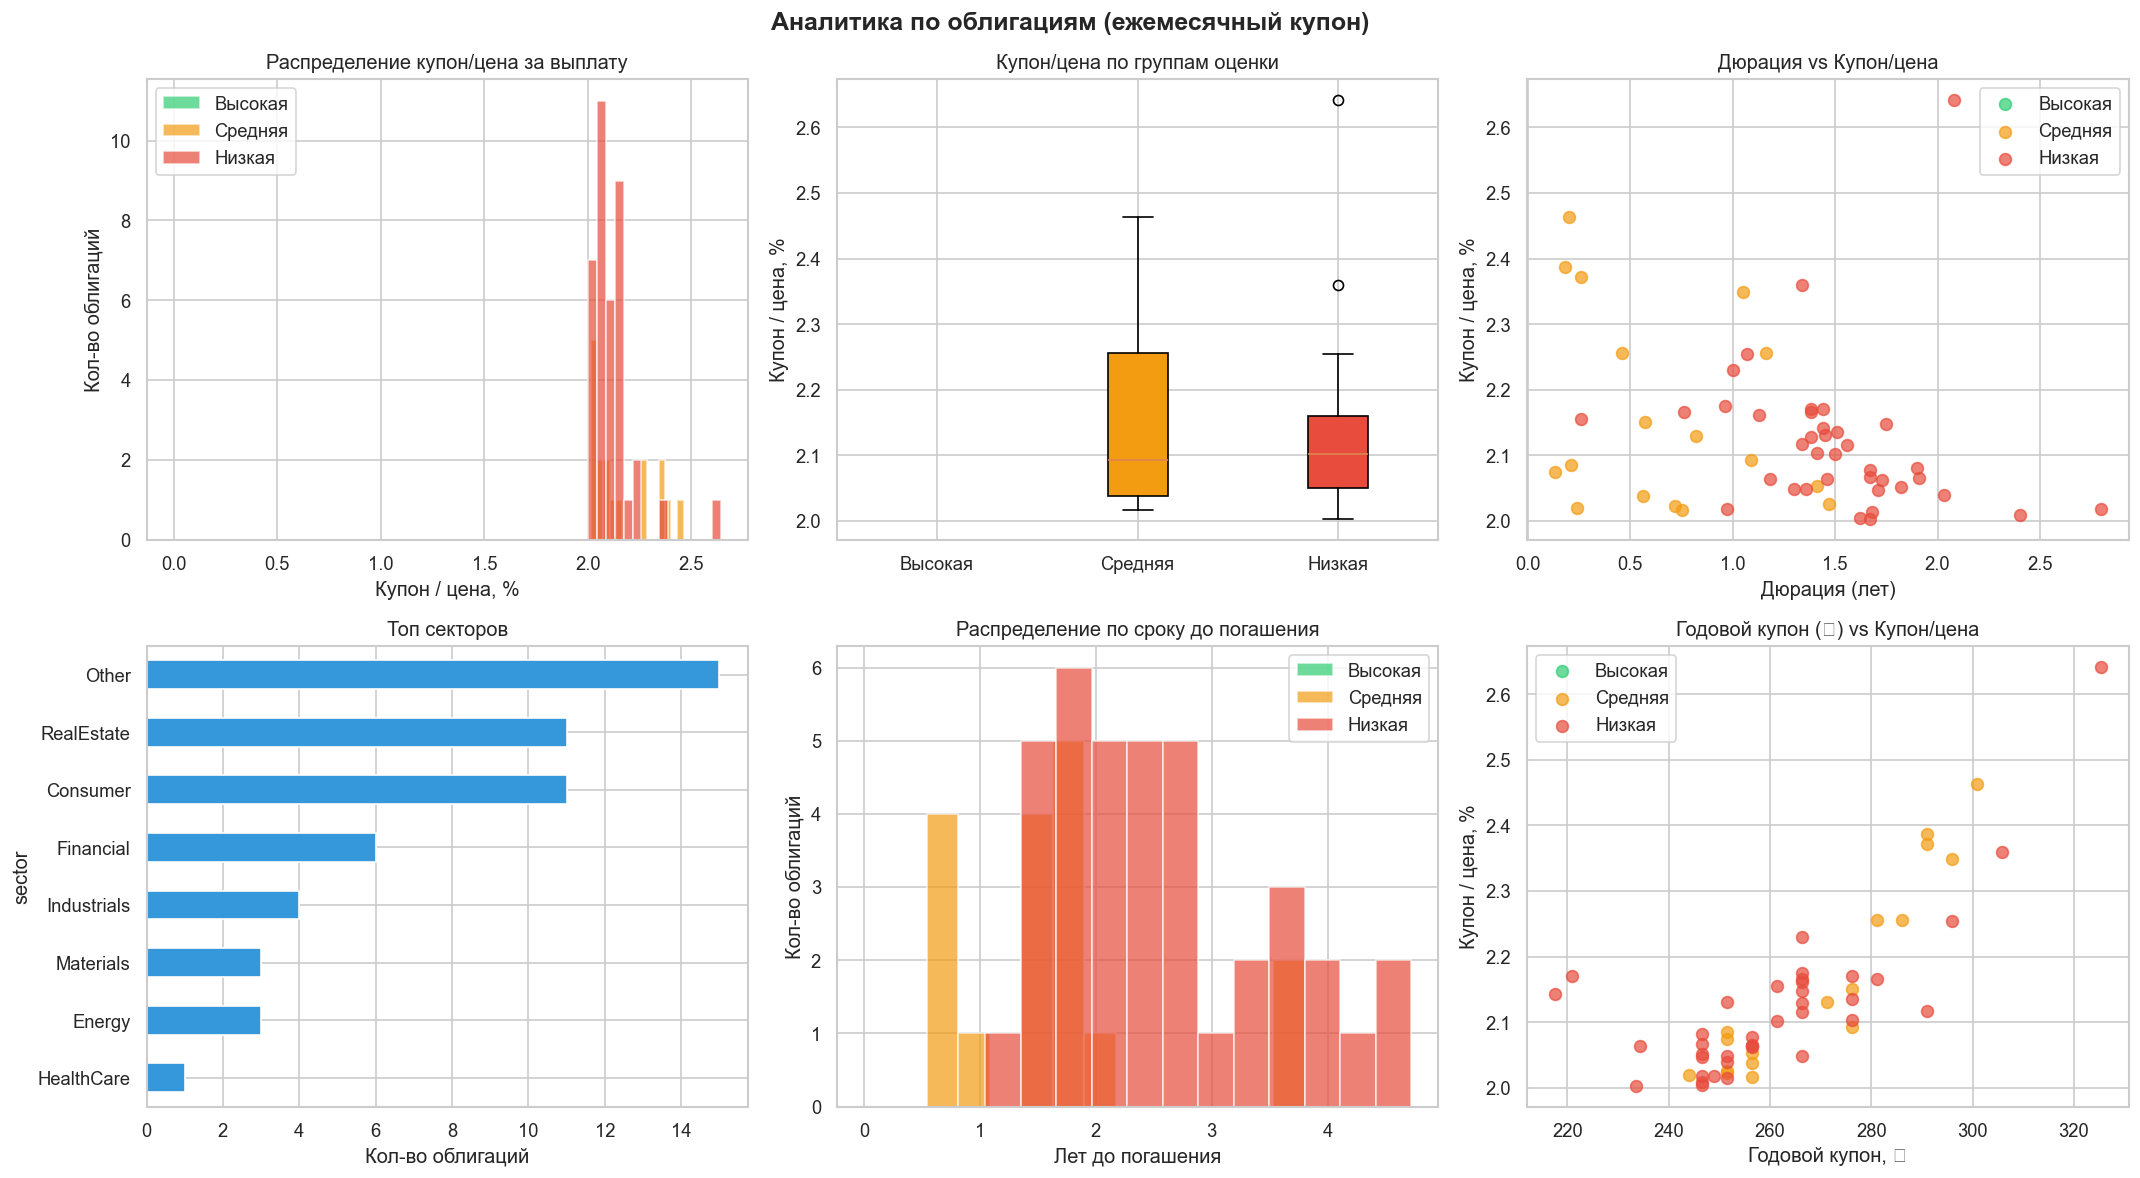

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Аналитика по облигациям (ежемесячный купон)", fontsize=15, fontweight="bold")

colors = {"Высокая": "#2ecc71", "Средняя": "#f39c12", "Низкая": "#e74c3c"}
order = ["Высокая", "Средняя", "Низкая"]

# 1. Распределение купон/цена по группам
ax = axes[0, 0]
for label in order:
    sub = df[df["rate_label"] == label]["coupon_to_price_pct"].dropna()
    ax.hist(sub, bins=15, alpha=0.7, label=label, color=colors[label])
ax.set_title("Распределение купон/цена за выплату")
ax.set_xlabel("Купон / цена, %")
ax.set_ylabel("Кол-во облигаций")
ax.legend()

# 2. Boxplot купон/цена по оценкам
ax = axes[0, 1]
data_box = [df[df["rate_label"] == l]["coupon_to_price_pct"].dropna() for l in order]
bp = ax.boxplot(data_box, patch_artist=True, labels=order)
for patch, label in zip(bp["boxes"], order):
    patch.set_facecolor(colors[label])
ax.set_title("Купон/цена по группам оценки")
ax.set_ylabel("Купон / цена, %")

# 3. Scatter: дюрация vs купон/цена
ax = axes[0, 2]
for label in order:
    sub = df[df["rate_label"] == label]
    ax.scatter(sub["duration"], sub["coupon_to_price_pct"], alpha=0.7,
               label=label, color=colors[label], s=50)
ax.set_title("Дюрация vs Купон/цена")
ax.set_xlabel("Дюрация (лет)")
ax.set_ylabel("Купон / цена, %")
ax.legend()

# 4. Топ секторов
ax = axes[1, 0]
sector_counts = df["sector"].value_counts().head(10)
sector_counts.plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Топ секторов")
ax.set_xlabel("Кол-во облигаций")
ax.invert_yaxis()

# 5. Срок до погашения
ax = axes[1, 1]
for label in order:
    sub = df[df["rate_label"] == label]["maturity_years"].dropna()
    ax.hist(sub, bins=12, alpha=0.7, label=label, color=colors[label])
ax.set_title("Распределение по сроку до погашения")
ax.set_xlabel("Лет до погашения")
ax.set_ylabel("Кол-во облигаций")
ax.legend()

# 6. Годовой купон (₽) vs купон/цена
ax = axes[1, 2]
for label in order:
    sub = df[df["rate_label"] == label]
    ax.scatter(sub["annual_coupon"], sub["coupon_to_price_pct"],
               alpha=0.7, label=label, color=colors[label], s=50)
ax.set_title("Годовой купон (₽) vs Купон/цена")
ax.set_xlabel("Годовой купон, ₽")
ax.set_ylabel("Купон / цена, %")
ax.legend()

plt.tight_layout()
plt.show()

## Дополнительная аналитика

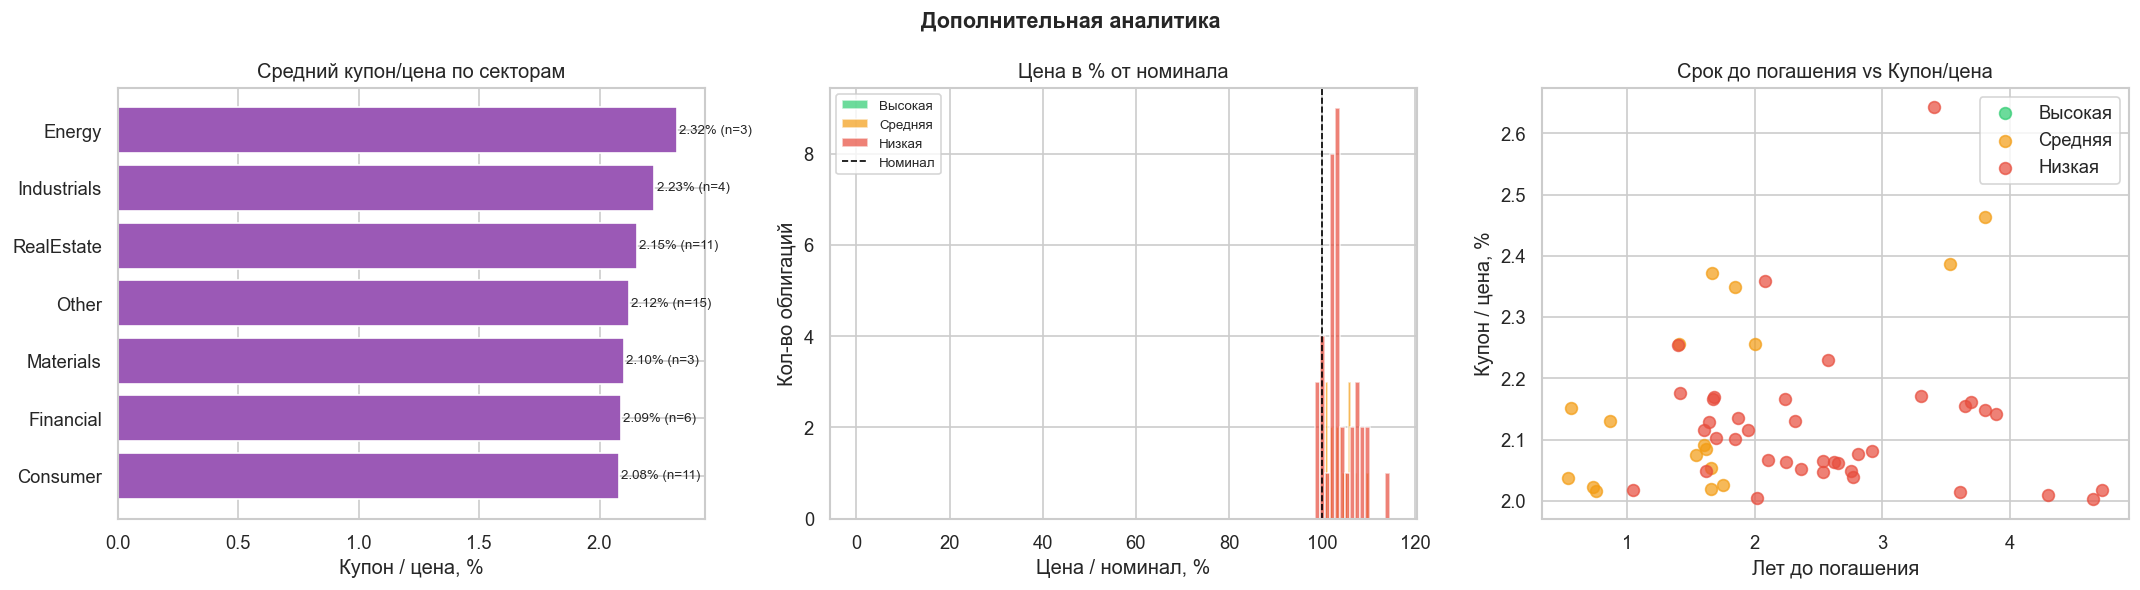

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Дополнительная аналитика", fontsize=13, fontweight="bold")

# 1. Средний купон/цена по секторам
ax = axes[0]
sector_yield = (
    df.groupby("sector")["coupon_to_price_pct"]
    .agg(["mean", "count"])
    .query("count >= 2")
    .sort_values("mean", ascending=True)
)
bars = ax.barh(sector_yield.index, sector_yield["mean"], color="#9b59b6")
ax.set_title("Средний купон/цена по секторам")
ax.set_xlabel("Купон / цена, %")
for bar, (_, row) in zip(bars, sector_yield.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{row['mean']:.2f}% (n={int(row['count'])})", va="center", fontsize=8)

# 2. Цена в % от номинала
ax = axes[1]
df["price_to_face"] = df["price_last"] / df["face_value"] * 100
for label in order:
    sub = df[df["rate_label"] == label]["price_to_face"].dropna()
    ax.hist(sub, bins=15, alpha=0.7, label=label, color=colors[label])
ax.axvline(100, color="black", linestyle="--", linewidth=1, label="Номинал")
ax.set_title("Цена в % от номинала")
ax.set_xlabel("Цена / номинал, %")
ax.set_ylabel("Кол-во облигаций")
ax.legend(fontsize=8)

# 3. Срок до погашения vs купон/цена
ax = axes[2]
for label in order:
    sub = df[df["rate_label"] == label]
    ax.scatter(sub["maturity_years"], sub["coupon_to_price_pct"],
               alpha=0.7, label=label, color=colors[label], s=50)
ax.set_title("Срок до погашения vs Купон/цена")
ax.set_xlabel("Лет до погашения")
ax.set_ylabel("Купон / цена, %")
ax.legend()

plt.tight_layout()
plt.show()